In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import cartopy.crs as ccrs
import cmocean.cm as cmo
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxparrow import fixed_point, geostrophy, minimization_based
from jaxparrow.utils import kinematics


jax.config.update("jax_enable_x64", True)

In [4]:
import sys

sys.path.append("../../tests")

import gaussian_eddy

For validation purpose we consider an idealized circular and axisymmetric eddy as analytical solutions can be derived in that setting using the gradient wind equation.

## Simulating the eddy

In [5]:
lat, lon, ssh, ug, vg, ucg, vcg, land_mask = gaussian_eddy.simulate_gaussian_eddy(R0=50e3, eta0=-.2)

W0401 14:32:06.590635 1290506 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


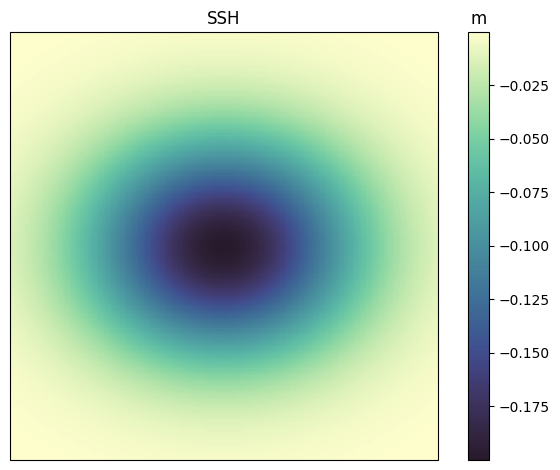

In [6]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

im = ax.pcolormesh(lon, lat, ssh, cmap=cmo.deep_r)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.set_title("m")
ax.set_title("SSH")

fig.tight_layout()

plt.show()

## Geostrophy

### Analytical solution

$u_g = 2y \frac{g \eta_0}{f R_0^2} \exp^{-(r/R_0)^2} = 2y \frac{g \eta}{f R_0^2}$

$v_g = -2x \frac{g \eta_0}{f R_0^2} \exp^{-(r/R_0)^2} = -2x \frac{g \eta}{f R_0^2}$

In [7]:
uvg = kinematics.magnitude(ug, vg)
uvcg = kinematics.magnitude(ucg, vcg)

max_diff = jnp.nanmax(jnp.abs(uvcg - uvg))

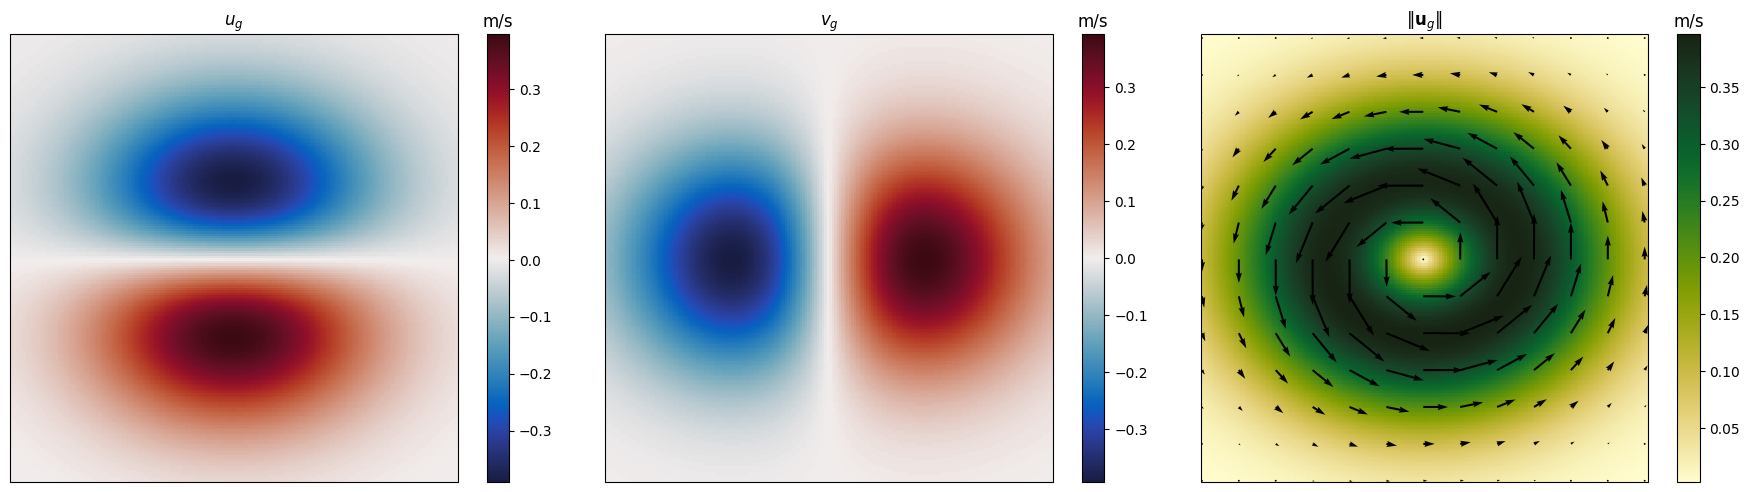

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={"projection": ccrs.PlateCarree()})

ax1.set_title("$u_g$")
im = ax1.pcolormesh(lon, lat, ug, cmap=cmo.balance)
cbar = plt.colorbar(im, ax=ax1)
cbar.ax.set_title("m/s")

ax2.set_title("$v_g$")
im = ax2.pcolormesh(lon, lat, vg, cmap=cmo.balance)
cbar = plt.colorbar(im, ax=ax2)
cbar.ax.set_title("m/s")

ax3.set_title("$\| \mathbf{u}_g \|$")
im = ax3.pcolormesh(lon, lat, uvg, cmap=cmo.speed)
cbar = plt.colorbar(im, ax=ax3)
cbar.ax.set_title("m/s")
ax3.quiver(lon[::15, ::15], lat[::15, ::15], ug[::15, ::15], vg[::15, ::15], color="k")

fig.tight_layout()

plt.show()

### Numerical solution

$f\mathbf{k} \times \mathbf{u_g} = -g \nabla \eta$

In [9]:
ug_est, vg_est = geostrophy(ssh, lat, lon, rotate_to_geographic=False)

ug_est = ug_est.at[(0, -1), :].set(jnp.nan)
ug_est = ug_est.at[:, (0, -1)].set(jnp.nan)
vg_est = vg_est.at[(0, -1), :].set(jnp.nan)
vg_est = vg_est.at[:, (0, -1)].set(jnp.nan)

uvg_est = kinematics.magnitude(ug_est, vg_est)

num_diff = ((ug_est - ug)**2 + (vg_est - vg)**2)**0.5

In [10]:
jnp.nanmean(num_diff), jnp.nanmax(num_diff)

(Array(0.0004939, dtype=float64), Array(0.00111514, dtype=float64))

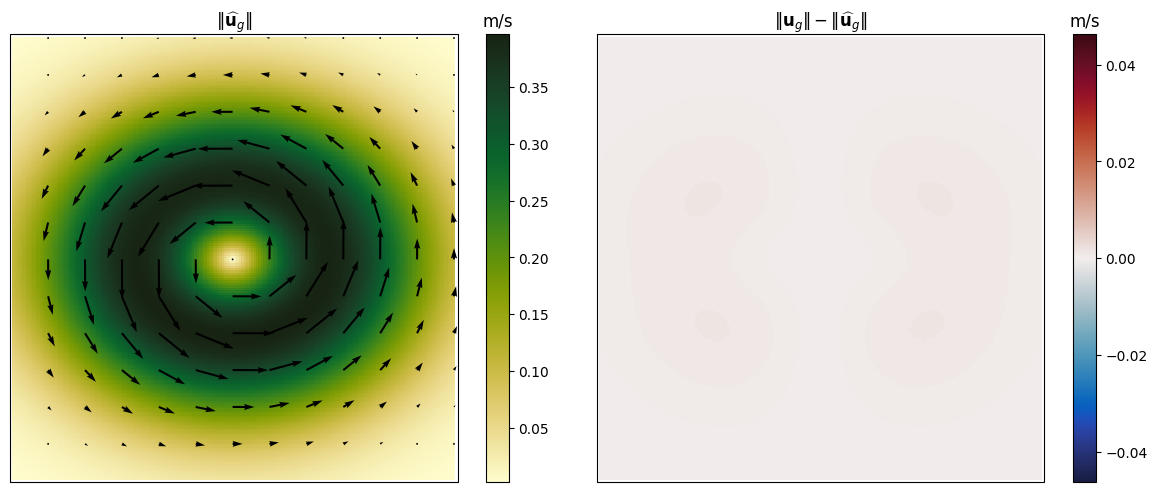

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={"projection": ccrs.PlateCarree()})
ax1, ax2 = axes.flatten()

ax1.set_title("$\| \widehat{\mathbf{u}}_g \|$")
im = ax1.pcolormesh(lon, lat, uvg_est, cmap=cmo.speed)
cbar = plt.colorbar(im, ax=ax1)
cbar.ax.set_title("m/s")
ax1.quiver(lon[::15, ::15], lat[::15, ::15], ug_est[::15, ::15], vg_est[::15, ::15], color="k")

ax2.set_title("$\| \mathbf{u}_g \| - \| \widehat{\mathbf{u}}_g \| $")
im = ax2.pcolormesh(lon, lat, num_diff, cmap=cmo.balance, vmin=-max_diff, vmax=max_diff)
cbar = plt.colorbar(im, ax=ax2)
cbar.ax.set_title("m/s")

fig.tight_layout() 

plt.show()

## Cyclogeostrophy

### Analytical - gradient wind solution

$V_{gw}=\frac{2V_g}{1+\sqrt{1+4V_g/(fr)}}$

$u_{gw} = -V_{gw} \frac{y}{r}$

$v_{gw} = V_{gw} \frac{x}{r}$

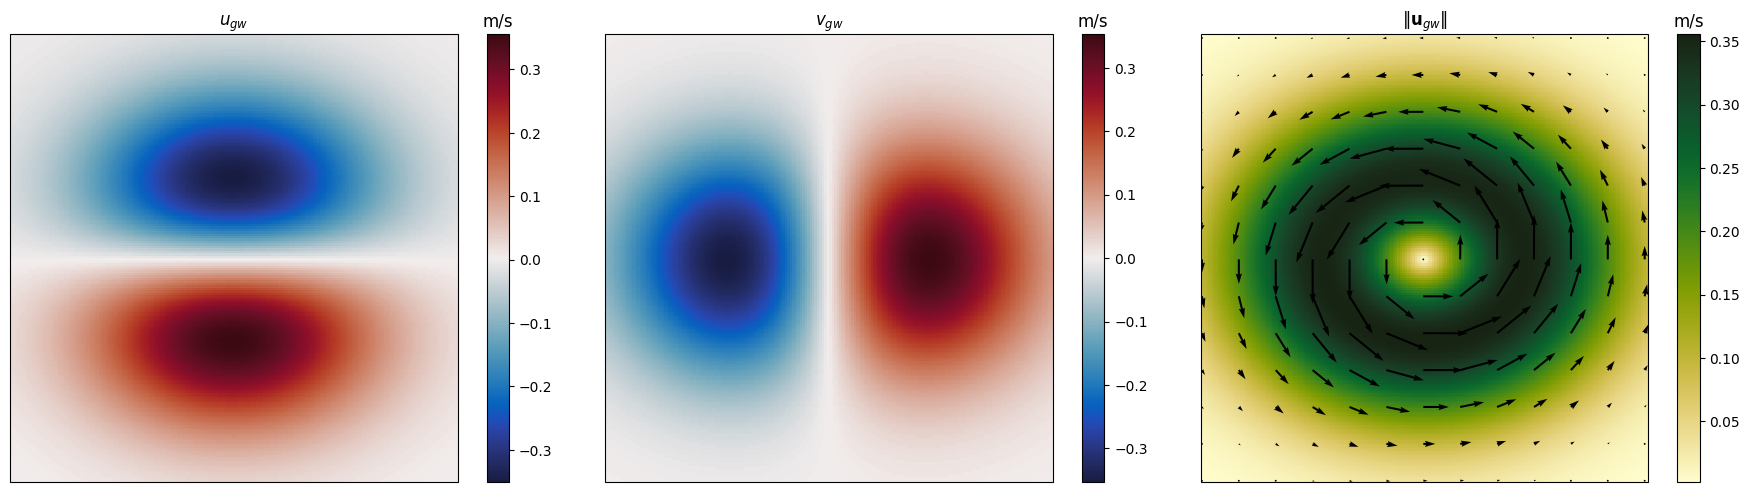

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={"projection": ccrs.PlateCarree()})

ax1.set_title("$u_{gw}$")
im = ax1.pcolormesh(lon, lat, ucg, cmap=cmo.balance)
cbar = plt.colorbar(im, ax=ax1)
cbar.ax.set_title("m/s")

ax2.set_title("$v_{gw}$")
im = ax2.pcolormesh(lon, lat, vcg, cmap=cmo.balance)
cbar = plt.colorbar(im, ax=ax2)
cbar.ax.set_title("m/s")

ax3.set_title("$\| \mathbf{u}_{gw} \|$")
im = ax3.pcolormesh(lon, lat, uvcg, cmap=cmo.speed)
cbar = plt.colorbar(im, ax=ax3)
cbar.ax.set_title("m/s")
ax3.quiver(lon[::15, ::15], lat[::15, ::15], ucg[::15, ::15], vcg[::15, ::15], color="k")

fig.tight_layout()

plt.show()

### Numerical solutions

#### Geostrophic estimation

$f\mathbf{k} \times \mathbf{u_g} = -g \nabla \eta$

In [ ]:
cyclo_diff = ((ucg - ug_est)**2 + (vcg - vg_est)**2)**0.5

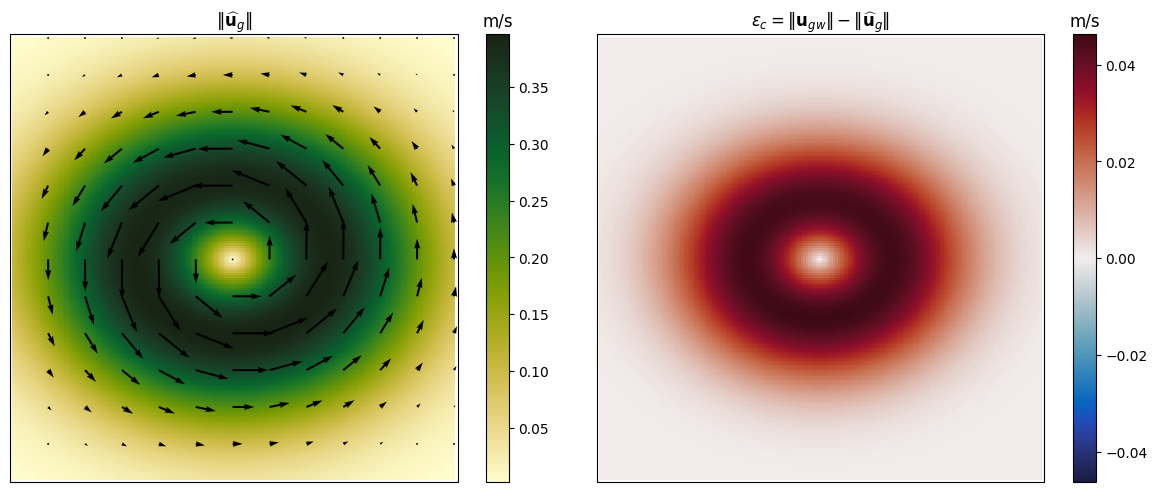

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={"projection": ccrs.PlateCarree()})
ax1, ax2 = axes.flatten()

ax1.set_title("$\| \widehat{\mathbf{u}}_g \|$")
im = ax1.pcolormesh(lon, lat, uvg_est, cmap=cmo.speed)
cbar = plt.colorbar(im, ax=ax1)
cbar.ax.set_title("m/s")
ax1.quiver(lon[::15, ::15], lat[::15, ::15], ug_est[::15, ::15], vg_est[::15, ::15], color="k")

ax2.set_title("$\\varepsilon_c = \| \mathbf{u}_{gw} \| - \| \widehat{\mathbf{u}}_g \|$")
im = ax2.pcolormesh(lon, lat, cyclo_diff, cmap=cmo.balance, vmin=-max_diff, vmax=max_diff)
cbar = plt.colorbar(im, ax=ax2)
cbar.ax.set_title("m/s")

fig.tight_layout()

plt.show()

#### Minimization-based estimation

$\mathbf{u} - \frac{\mathbf{k}}{f} \times (\mathbf{u} \cdot \nabla \mathbf{u}) = \mathbf{u_g}$

$\mathbf{u}_{cg,MB} = \arg \min_{\mathbf{u}} \| \mathbf{u} - \mathbf{u_g} - \frac{\mathbf{k}}{f} \times (\mathbf{u} \cdot \nabla \mathbf{u}) \|$

In [13]:
mb_res = minimization_based(lat_t=lat, lon_t=lon, ssh_t=ssh, rotate_to_geographic=False)

umb_est = mb_res.ucg
vmb_est = mb_res.vcg

umb_est = umb_est.at[(0, -1), :].set(jnp.nan)
umb_est = umb_est.at[:, (0, -1)].set(jnp.nan)
vmb_est = vmb_est.at[(0, -1), :].set(jnp.nan)
vmb_est = vmb_est.at[:, (0, -1)].set(jnp.nan)

uvmb_est = kinematics.magnitude(umb_est, vmb_est)

mb_diff = ((ucg - umb_est)**2 + (vcg - vmb_est)**2)**0.5
mb_imp = jnp.abs(cyclo_diff) - jnp.abs(mb_diff)

max_imp = jnp.nanmax(jnp.abs(mb_imp / uvcg))

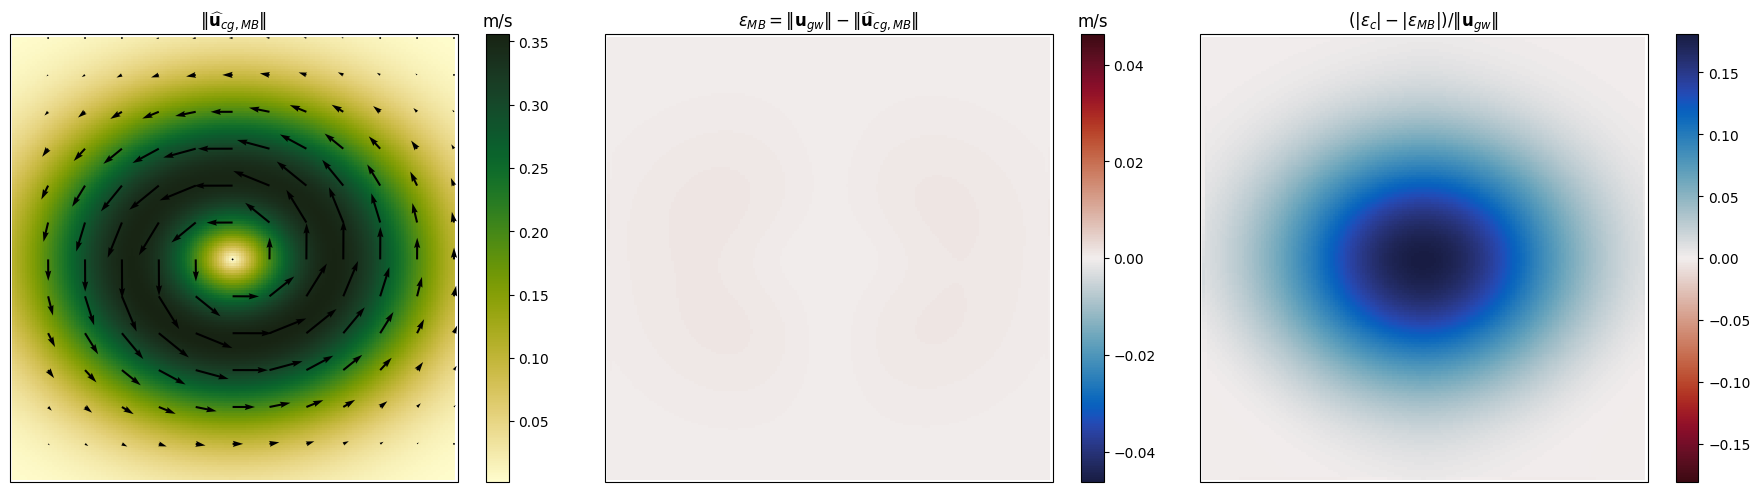

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={"projection": ccrs.PlateCarree()})

ax1.set_title("$\| \widehat{\mathbf{u}}_{cg,MB} \|$")
im = ax1.pcolormesh(lon, lat, uvmb_est, cmap=cmo.speed)
cbar = plt.colorbar(im, ax=ax1)
cbar.ax.set_title("m/s")
ax1.quiver(lon[::15, ::15], lat[::15, ::15], umb_est[::15, ::15], vmb_est[::15, ::15], color="k")

ax2.set_title("$\\varepsilon_{MB} = \| \mathbf{u}_{gw} \| - \| \widehat{\mathbf{u}}_{cg,MB} \|$")
im = ax2.pcolormesh(lon, lat, mb_diff, cmap=cmo.balance, vmax=max_diff, vmin=-max_diff)
ax2.set_aspect("equal")
cbar = plt.colorbar(im, ax=ax2)
cbar.ax.set_title("m/s")

ax3.set_title("$(|\\varepsilon_c| - |\\varepsilon_{MB}|) / \| \mathbf{u}_{gw} \|$")
im = ax3.pcolormesh(lon, lat, mb_imp / uvcg, cmap=cmo.balance_r, vmax=max_imp, vmin=-max_imp)
ax3.set_aspect("equal")
cbar = plt.colorbar(im, ax=ax3)

fig.tight_layout()

plt.show()

#### Fixed-point estimation

$\mathbf{u} - \frac{\mathbf{k}}{f} \times (\mathbf{u} \cdot \nabla \mathbf{u}) = \mathbf{u_g}$

$\mathbf{u}^{(n+1)} = \mathbf{u_g} + \frac{\mathbf{k}}{f} \times (\mathbf{u}^{(n)} \cdot \nabla \mathbf{u}^{(n)})$

In [15]:
fp_res = fixed_point(lat_t=lat, lon_t=lon, ssh_t=ssh, rotate_to_geographic=False)

ufp_est = fp_res.ucg
vfp_est = fp_res.vcg

ufp_est = ufp_est.at[(0, -1), :].set(jnp.nan)
ufp_est = ufp_est.at[:, (0, -1)].set(jnp.nan)
vfp_est = vfp_est.at[(0, -1), :].set(jnp.nan)
vfp_est = vfp_est.at[:, (0, -1)].set(jnp.nan)

uvfp_est = kinematics.magnitude(ufp_est, vfp_est)

fp_diff = ((ucg - ufp_est)**2 + (vcg - vfp_est)**2)**0.5
fp_imp = jnp.abs(cyclo_diff) - jnp.abs(fp_diff)

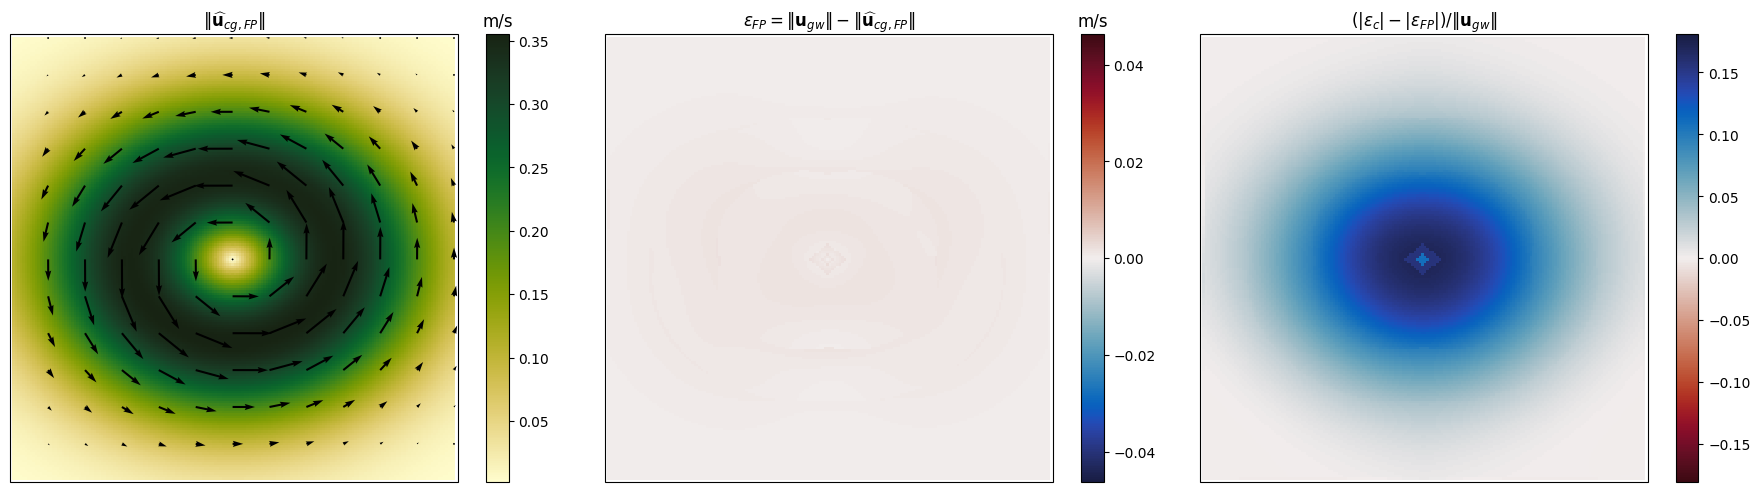

In [16]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={"projection": ccrs.PlateCarree()})

ax1.set_title("$\| \widehat{\mathbf{u}}_{cg,FP} \|$")
im = ax1.pcolormesh(lon, lat, uvfp_est, cmap=cmo.speed)
cbar = plt.colorbar(im, ax=ax1)
cbar.ax.set_title("m/s")
ax1.quiver(lon[::15, ::15], lat[::15, ::15], ufp_est[::15, ::15], vfp_est[::15, ::15], color="k")

ax2.set_title("$\\varepsilon_{FP} = \| \mathbf{u}_{gw} \| - \| \widehat{\mathbf{u}}_{cg,FP} \|$")
im = ax2.pcolormesh(lon, lat, fp_diff, cmap=cmo.balance, vmax=max_diff, vmin=-max_diff)
cbar = plt.colorbar(im, ax=ax2)
cbar.ax.set_title("m/s")

ax3.set_title("$(|\\varepsilon_c| - |\\varepsilon_{FP}|) / \| \mathbf{u}_{gw} \|$")
im = ax3.pcolormesh(lon, lat, fp_imp / uvcg, cmap=cmo.balance_r, vmax=max_imp, vmin=-max_imp)
cbar = plt.colorbar(im, ax=ax3)

fig.tight_layout()

plt.show()

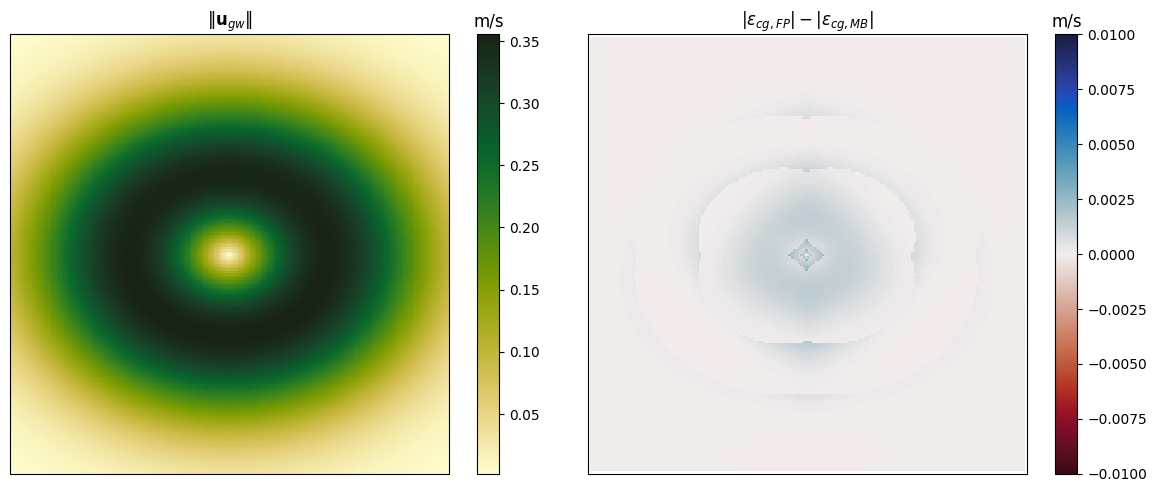

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={"projection": ccrs.PlateCarree()})

ax1.set_title("$\| \mathbf{u}_{gw} \|$")
im = ax1.pcolormesh(lon, lat, uvcg, cmap=cmo.speed)
cbar = plt.colorbar(im, ax=ax1)
cbar.ax.set_title("m/s")

# Difference: |ε_FP| - |ε_MB|
ax2.set_title("$|\\varepsilon_{cg,FP}| - |\\varepsilon_{cg,MB}|$")
im = ax2.pcolormesh(lon, lat, jnp.abs(fp_diff) - jnp.abs(mb_diff), cmap=cmo.balance_r, vmin=-0.01, vmax=0.01)
cbar = plt.colorbar(im, ax=ax2)
cbar.ax.set_title("m/s")

fig.tight_layout()

plt.show()